# **EDA of the Dataset**

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

In [29]:

# Set aesthetic style for presentation-ready plots
sns.set_theme(style="whitegrid", palette="muted")

print("--- 1. Loading Dataset ---")
df = pd.read_csv('pmos_longitudinal_dataset_FINALformodel.csv')

# --- Feature Engineering for Analysis ---
# 1. Message Length (How long are the patient complaints?)
df['message_word_count'] = df['current_portal_message'].apply(lambda x: len(str(x).split()))

# 2. Number of Historical Encounters (How fragmented is their history?)
# We count the number of brackets '[' which represent a distinct visit in our data
df['encounter_count'] = df['past_medical_history'].apply(lambda x: str(x).count('['))


--- 1. Loading Dataset ---



--- 2. Visualizing Class Distribution ---


/tmp/ipykernel_7065/1099750817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='clinical_priority', order=['LOW', 'MEDIUM', 'HIGH'], palette=['#2ecc71', '#f1c40f', '#e74c3c'])


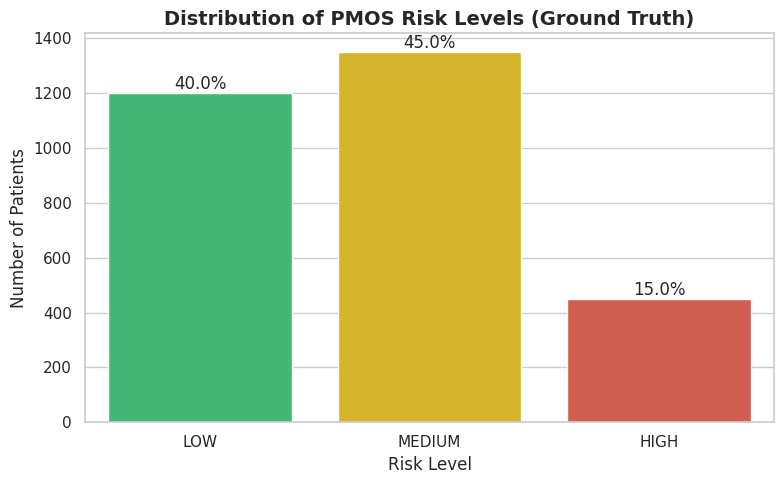

In [30]:
print("\n--- 2. Visualizing Class Distribution ---")
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='clinical_priority', order=['LOW', 'MEDIUM', 'HIGH'], palette=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title('Distribution of PMOS Risk Levels (Ground Truth)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients')
plt.xlabel('Risk Level')
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()



--- 3. Analyzing Patient Portal Message Length ---


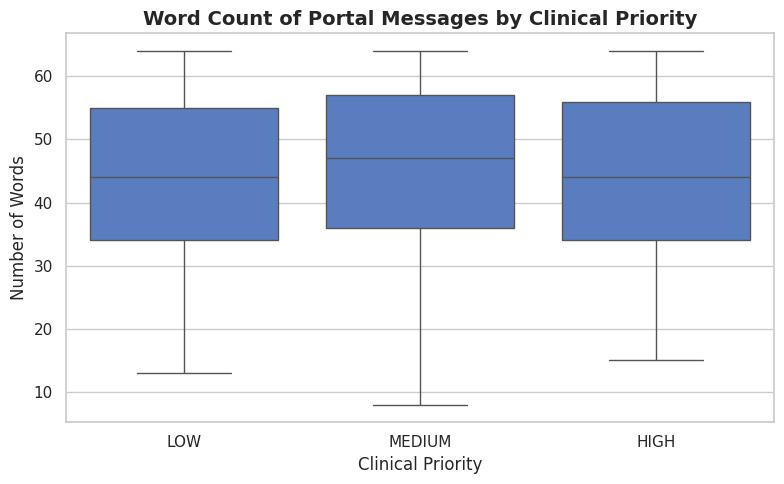

In [31]:
print("\n--- 3. Analyzing Patient Portal Message Length ---")
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='clinical_priority', y='message_word_count', order=['LOW', 'MEDIUM', 'HIGH'])
plt.title('Word Count of Portal Messages by Clinical Priority', fontsize=14, fontweight='bold')
plt.ylabel('Number of Words')
plt.xlabel('Clinical Priority')
plt.tight_layout()
plt.show()



--- 4. Analyzing Clinical Fragmentation (Historical Encounters) ---


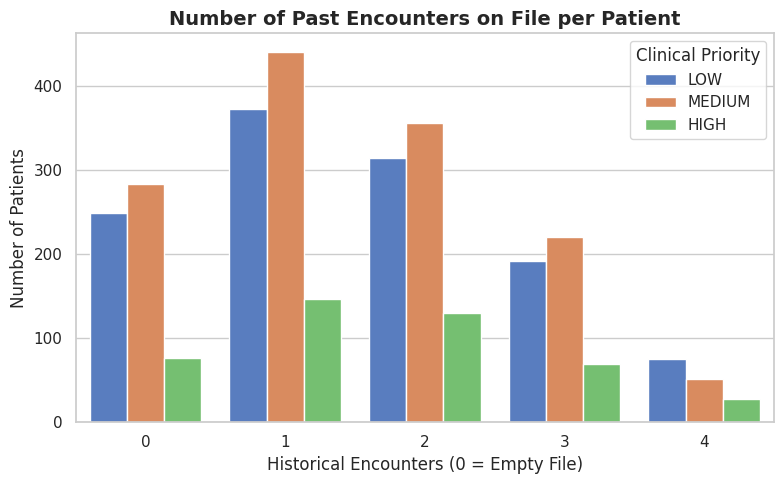

In [32]:
print("\n--- 4. Analyzing Clinical Fragmentation (Historical Encounters) ---")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='encounter_count', hue='clinical_priority', hue_order=['LOW', 'MEDIUM', 'HIGH'])
plt.title('Number of Past Encounters on File per Patient', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients')
plt.xlabel('Historical Encounters (0 = Empty File)')
plt.legend(title='Clinical Priority')
plt.tight_layout()
plt.show()



--- 5. Extracting Top Clinical Keywords (The TF-IDF Trap) ---


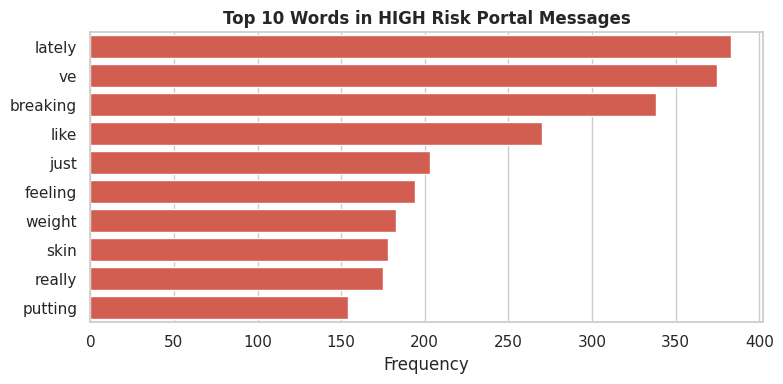

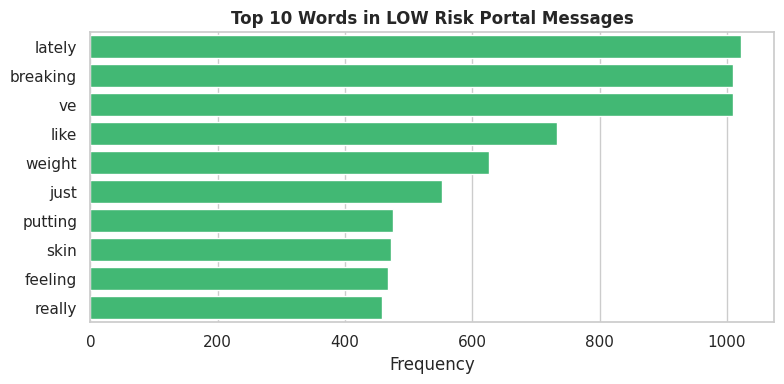

In [33]:
print("\n--- 5. Extracting Top Clinical Keywords (The TF-IDF Trap) ---")
# We want to see what words the patients are actually using in their portal messages
def plot_top_words(text_series, title, color):
    vec = CountVectorizer(stop_words='english', max_features=10)
    word_matrix = vec.fit_transform(text_series)
    word_counts = np.array(word_matrix.sum(axis=0)).flatten()
    word_freq = pd.DataFrame({'Word': vec.get_feature_names_out(), 'Count': word_counts})
    word_freq = word_freq.sort_values(by='Count', ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=word_freq, x='Count', y='Word', color=color)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Frequency')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# Plot for HIGH risk
plot_top_words(df[df['clinical_priority'] == 'HIGH']['current_portal_message'],
               'Top 10 Words in HIGH Risk Portal Messages', '#e74c3c')

# Plot for LOW risk
plot_top_words(df[df['clinical_priority'] == 'LOW']['current_portal_message'],
               'Top 10 Words in LOW Risk Portal Messages', '#2ecc71')

--- Generating UNIQUE Word Statistics for Clinical Priorities ---
Automatically ignoring these globally common words: ['lately', 'breaking', 'weight', 'skin', 'help', 'putting', 'work', 'pounds', 'stress', 'crazy']



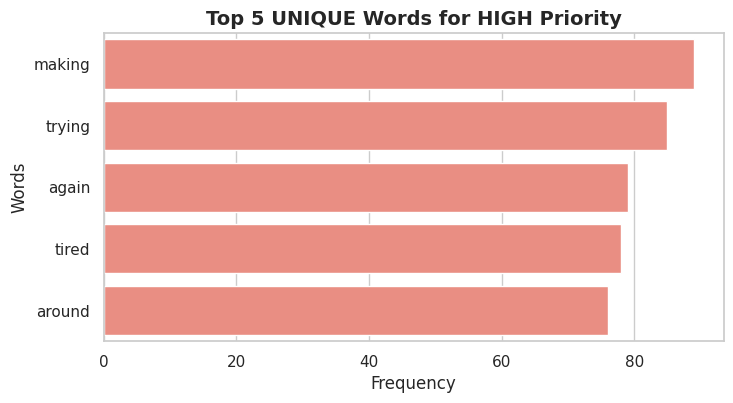

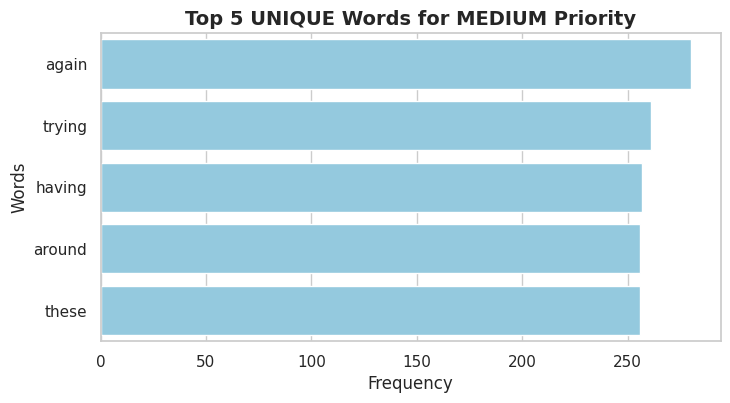

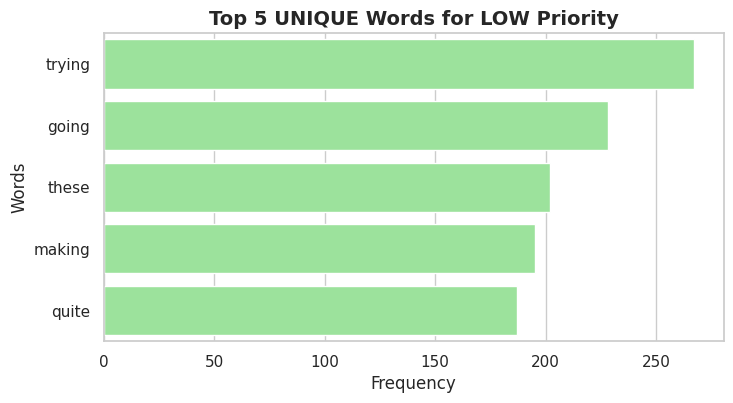

In [34]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("--- Generating UNIQUE Word Statistics for Clinical Priorities ---")

# 1. Base conversational noise
stop_words = {
    'and', 'the', 'to', 'my', 'i', 'have', 'been', 'for', 'with', 'of',
    'in', 'a', 'is', 'that', 'it', 'on', 'this', 'but', 'like', 'just',
    'about', 'some', 'very', 'really', 'also', 'what', 'when', 'they',
    'would', 'could', 'from', 'more', 'than', 'because', 'which', 'there',
    'their', 'were', 'was', 'are', 'not', 'get', 'got', 'out', 'into',
    'over', 'after', 'will', 'your', 'much', 'only', 'can', 'cant', 'even',
    "don't", 'dont', "i'm", 'im', "i've", 'ive', "i'll", 'ill', "it's", 'its',
    'feel', 'feeling', 'am', 'doing', 'since', 'please', 'know', 'need', 'want'
}

# 2. Find globally common words (the generic medical noise messing up the charts)
all_text = " ".join(df['current_portal_message'].astype(str).str.lower())
all_clean = re.sub(r'[^\w\s]', '', all_text)
all_words = [w for w in all_clean.split() if w not in stop_words and len(w) > 3]

# Dynamically find the top 10 most common words in the ENTIRE dataset
# and add them to the stop_words so they don't dominate the individual charts
global_top_10 = [word for word, count in Counter(all_words).most_common(10)]
stop_words.update(global_top_10)
print(f"Automatically ignoring these globally common words: {global_top_10}\n")

# 3. Function to create a frequent words chart for each priority level
def plot_top_words_per_priority(df, priority_level, color):
    raw_text = " ".join(df[df['clinical_priority'] == priority_level]['current_portal_message'].astype(str).str.lower())
    clean_text = re.sub(r'[^\w\s]', '', raw_text)

    words = [w for w in clean_text.split() if w not in stop_words and len(w) > 3]

    common_words = Counter(words).most_common(5)
    words_list, counts_list = zip(*common_words)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(counts_list), y=list(words_list), color=color)
    plt.title(f"Top 5 UNIQUE Words for {priority_level} Priority", fontsize=14, fontweight='bold')
    plt.xlabel("Frequency", fontsize=12)
    plt.ylabel("Words", fontsize=12)
    plt.show()

# Generate the 3 charts
plot_top_words_per_priority(df, 'HIGH', 'salmon')
plot_top_words_per_priority(df, 'MEDIUM', 'skyblue')
plot_top_words_per_priority(df, 'LOW', 'lightgreen')

--- Generating Box Plot for Message Lengths ---


/tmp/ipykernel_7065/2533507723.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clinical_priority', y='message_word_count', data=df,


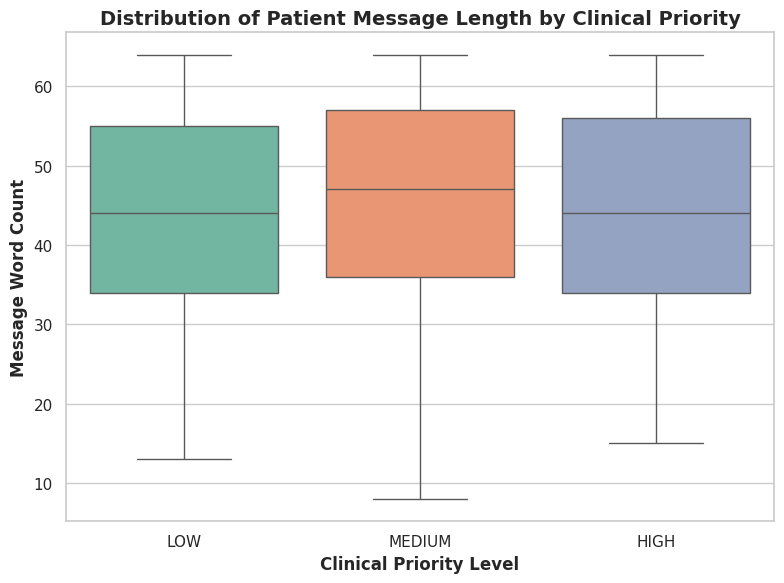

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Generating Box Plot for Message Lengths ---")
plt.figure(figsize=(8, 6))
sns.boxplot(x='clinical_priority', y='message_word_count', data=df,
            order=['LOW', 'MEDIUM', 'HIGH'], palette='Set2')

plt.title('Distribution of Patient Message Length by Clinical Priority', fontsize=14, fontweight='bold')
plt.xlabel('Clinical Priority Level', fontsize=12, fontweight='bold')
plt.ylabel('Message Word Count', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# **Baseline TF-IDF + Logistic Regression**

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [37]:
print("--- 1. Loading the Longitudinal Dataset ---")
# Load the dataset you just generated
df = pd.read_csv('pmos_longitudinal_dataset_FINALformodel.csv')

# We combine the fragmented history and the current message into one text block
# to give the baseline model a fair chance at reading everything.
df['full_text'] = df['past_medical_history'] + " \n Patient says: " + df['current_portal_message']

print(f"Dataset loaded with {len(df)} records.\n")


--- 1. Loading the Longitudinal Dataset ---
Dataset loaded with 3000 records.



In [38]:
print("--- 2. Exploratory Data Analysis (EDA) ---")
# Check the class distribution to prove your data engineering worked
dist = df['clinical_priority'].value_counts(normalize=True) * 100
print("Class Distribution (%):")
print(dist.round(1))

# Optional: Plot the distribution (uncomment to see the chart in Colab)
# sns.countplot(data=df, x='clinical_priority', order=['LOW', 'MEDIUM', 'HIGH'])
# plt.title('Distribution of PMOS Risk Levels')
# plt.show()

--- 2. Exploratory Data Analysis (EDA) ---
Class Distribution (%):
clinical_priority
MEDIUM    45.0
LOW       40.0
HIGH      15.0
Name: proportion, dtype: float64


In [39]:
print("\n--- 3. Preparing Data for Machine Learning ---")
# Split into 80% Training and 20% Testing
# The 'stratify' parameter locks in the exact distribution!
X_train, X_test, y_train, y_test = train_test_split(
    df['current_portal_message'], # <--- THE REAL-WORLD MESSY TEXT
    df['clinical_priority'],
    test_size=0.20,
    random_state=42,
    stratify=df['clinical_priority']
)
print(f"Training on {len(X_train)} records, Testing on {len(X_test)} records...\n")

# PROOF OF DISTRIBUTION:
print("Train Set Distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(1))

print("\nTest Set Distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(1))


--- 3. Preparing Data for Machine Learning ---
Training on 2400 records, Testing on 600 records...

Train Set Distribution (%):
clinical_priority
MEDIUM    45.0
LOW       40.0
HIGH      15.0
Name: proportion, dtype: float64

Test Set Distribution (%):
clinical_priority
MEDIUM    45.0
LOW       40.0
HIGH      15.0
Name: proportion, dtype: float64


In [40]:
print("\n--- 4. Building the Classical Baseline (TF-IDF + Logistic Regression) ---")
# Step A: Convert words to numbers (Term Frequency - Inverse Document Frequency)
vectorizer = TfidfVectorizer(max_features=1500, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Step B: Train a Logistic Regression Model
# We use class_weight='balanced' to force the model to pay attention to the rare HIGH risk cases
baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline_model.fit(X_train_vec, y_train)

print("Training Complete!\n")



--- 4. Building the Classical Baseline (TF-IDF + Logistic Regression) ---
Training Complete!



In [41]:
print("--- 5. Evaluating the Baseline ---")
y_pred = baseline_model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {acc:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, labels=['LOW', 'MEDIUM', 'HIGH']))


--- 5. Evaluating the Baseline ---
Baseline Accuracy: 0.548

Classification Report:
              precision    recall  f1-score   support

         LOW       0.57      0.58      0.58       240
      MEDIUM       0.69      0.58      0.63       270
        HIGH       0.25      0.36      0.29        90

    accuracy                           0.55       600
   macro avg       0.50      0.51      0.50       600
weighted avg       0.58      0.55      0.56       600




--- 6. Generating Presentation-Ready Confusion Matrix ---


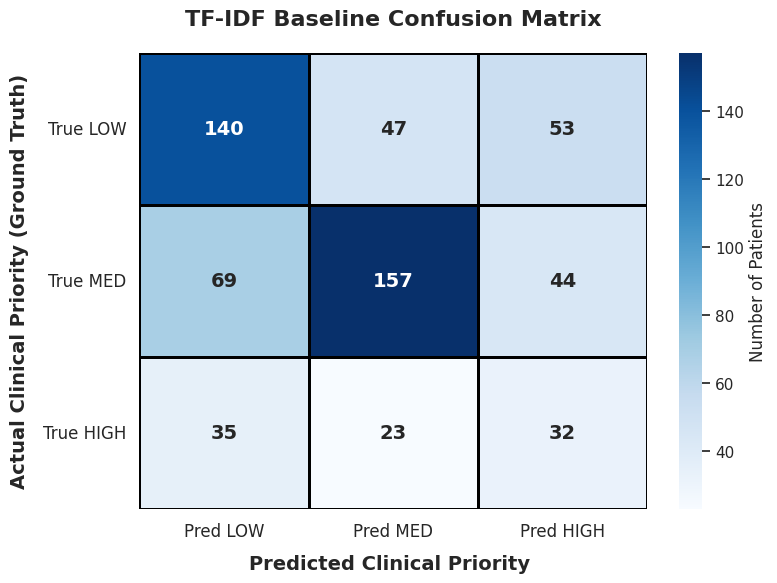

In [49]:
print("\n--- 6. Generating Presentation-Ready Confusion Matrix ---")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Create a heatmap using Seaborn
# 'cmap="Blues"' provides a clean, academic look.
# 'annot=True' ensures the actual numbers are printed inside the boxes.
ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black',
    cbar_kws={'label': 'Number of Patients'},
    xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
    yticklabels=['True LOW', 'True MED', 'True HIGH'],
    annot_kws={"size": 14, "weight": "bold"} # Makes numbers highly visible for slides
)

# Add professional styling and labels
plt.title('TF-IDF Baseline Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Clinical Priority ', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Actual Clinical Priority (Ground Truth)', fontsize=14, fontweight='bold', labelpad=10)

# Adjust tick formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

# Ensure everything fits perfectly
plt.tight_layout()
plt.show()

# **Baseline SVM**

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("--- 1. Loading the Noisy Longitudinal Dataset ---")
df = pd.read_csv('pmos_longitudinal_dataset_FINALformodel.csv')


--- 1. Loading the Noisy Longitudinal Dataset ---


In [44]:
print("--- 2. Preparing Data (Portal Messages Only) ---")
# We strictly use the portal message to avoid the "cheat code" data leakage
X_train, X_test, y_train, y_test = train_test_split(
    df['current_portal_message'],
    df['clinical_priority'],
    test_size=0.20,
    random_state=42,
    stratify=df['clinical_priority']
)


--- 2. Preparing Data (Portal Messages Only) ---


In [45]:
print("\n--- 3. Building the SVM Baseline ---")
vectorizer = TfidfVectorizer(max_features=1500, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# LinearSVC is highly optimized for Text Classification
# We use class_weight='balanced' to force it to care about the 15% HIGH risk group
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model.fit(X_train_vec, y_train)

print("SVM Training Complete!\n")



--- 3. Building the SVM Baseline ---
SVM Training Complete!



In [46]:
print("--- 4. Evaluating the SVM ---")
y_pred_svm = svm_model.predict(X_test_vec)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {acc_svm:.3f}\n")
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, labels=['LOW', 'MEDIUM', 'HIGH']))


--- 4. Evaluating the SVM ---
SVM Accuracy: 0.560

SVM Classification Report:
              precision    recall  f1-score   support

         LOW       0.57      0.59      0.58       240
      MEDIUM       0.66      0.63      0.64       270
        HIGH       0.27      0.28      0.27        90

    accuracy                           0.56       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.56      0.56      0.56       600




--- 5. Generating Presentation-Ready SVM Confusion Matrix ---


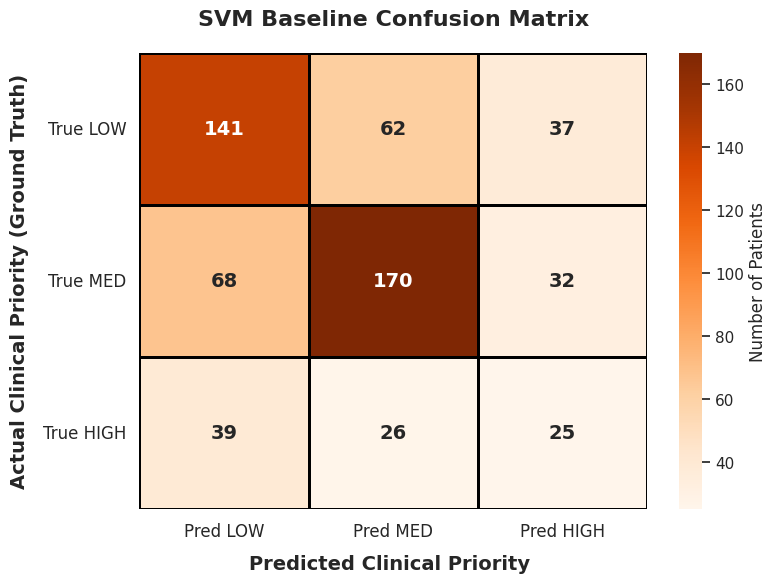

In [48]:
print("\n--- 5. Generating Presentation-Ready SVM Confusion Matrix ---")

# Calculate the confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=['LOW', 'MEDIUM', 'HIGH'])

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Create a heatmap using Seaborn
# We use 'Oranges' here so your slides clearly distinguish the SVM from the Logistic Regression (Blues)
ax = sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    linewidths=1,
    linecolor='black',
    cbar_kws={'label': 'Number of Patients'},
    xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
    yticklabels=['True LOW', 'True MED', 'True HIGH'],
    annot_kws={"size": 14, "weight": "bold"}
)

# Add professional styling and labels
plt.title('SVM Baseline Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Clinical Priority ', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Actual Clinical Priority (Ground Truth)', fontsize=14, fontweight='bold', labelpad=10)

# Adjust tick formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

# Ensure everything fits perfectly
plt.tight_layout()
plt.show()